# Grovers Algorithmus (6 Qubits)

In diesem Notebook implementierst du **Schritt für Schritt** Grovers Suchalgorithmus mit Qiskit, um mehrere markierte Einträge in einer unsortierten Datenbank aus $N = 2^6 = 64$ Elementen zu finden.

## Die Problemstellung

Gegeben ist eine unsortierte Liste von $N$ Elementen, von denen $M$ Elemente "markiert" sind (die gesuchten Lösungen). Eine Black-Box-Funktion (das **Orakel**)

$$f(x) = \begin{cases} 1 & \text{falls } x \text{ eine Lösung ist} \\ 0 & \text{sonst} \end{cases}$$

kann geprüft werden, aber wir kennen die Lösungen nicht im Voraus.

**Klassisch** braucht man im Schnitt $O(N/M)$ Anfragen, um eine Lösung zu finden (man muss im Wesentlichen raten und nachschlagen).

**Grovers Algorithmus** findet eine Lösung mit hoher Wahrscheinlichkeit in nur $O(\sqrt{N/M})$ Anfragen an das Orakel – eine quadratische Beschleunigung.

In diesem Notebook suchen wir nach $M=3$ markierten Bitstrings unter $N=64$ möglichen 6-Bit-Strings.

## Wie funktioniert der Algorithmus? (Kurzüberblick)

Grovers Algorithmus arbeitet in Runden, den sogenannten **Grover-Iterationen**. Jede Iteration besteht aus zwei Teilen:

1. **Phasenorakel $Z_f$:** Kippt das Vorzeichen (die Phase) genau der Zustände, die Lösungen sind: $Z_f|x\rangle = (-1)^{f(x)}|x\rangle$.
2. **Diffusions-Operator (Inversion um den Mittelwert):** Realisiert durch $H^{\otimes n} \, Z_{OR} \, H^{\otimes n}$, wobei $Z_{OR}$ die Phase aller Zustände außer $|00\ldots0\rangle$ umkehrt.

Zusammen bewirken diese beiden Schritte geometrisch eine **Rotation** des Zustandsvektors in Richtung der gesuchten Lösungen. Wiederholt man diese Rotation oft genug, landet der Zustand (fast) exakt auf der Superposition der Lösungen, sodass eine Messung mit hoher Wahrscheinlichkeit eine Lösung liefert.

Wie oft man iterieren muss, leiten wir weiter unten geometrisch her.

## Schritt 1: Imports und Suchproblem definieren

Wie immer zuerst die Imports, sowie die Festlegung der gesuchten Bitstrings (`keys`). Diese Zellen sind vollständig vorgegeben – führe sie einfach aus.

In [1]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.circuit.library import PhaseOracleGate
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np

N_QUBITS = 6
N = 1 << N_QUBITS

keys = [
    "111000",
    "111100",
    "111110",
]
keys = [key[::-1] for key in keys]  # reverse: Qiskit erwartet Little Endian
NUM_SOLUTIONS = len(keys)


## Schritt 2: Das Phasenorakel $Z_f$ bauen

Wir brauchen ein Gatter, das für jeden Lösungs-Bitstring $x$ die Phase umkehrt: $Z_f|x\rangle = -|x\rangle$ für $x \in \{\text{keys}\}$, und $Z_f|x\rangle = |x\rangle$ sonst.

Dazu bauen wir zuerst einen booleschen Ausdruck, der genau dann `True` ist, wenn $x$ einer der gesuchten Bitstrings ist: für jeden Key eine Konjunktion (`&`) der passenden Literale, verknüpft über ein logisches ODER (`|`). Danach übergeben wir diesen Ausdruck an [`PhaseOracleGate`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.PhaseOracleGate), das (anders als `BitFlipOracleGate`) direkt die Phase manipuliert, statt ein Hilfs-Qubit zu benötigen.

Diese Zelle ist vollständig vorgegeben:

In [2]:
def expression_for_key(key):
    literals = [f'{"~" if int(val) == 0 else ""}x{i}' for i, val in enumerate(key, 1)]
    return '(' + ' & '.join(literals) + ')'

keys_expression = ' | '.join([expression_for_key(key) for key in keys])

Z_f = PhaseOracleGate(
    keys_expression,
    var_order=[f"x{n+1}" for n in range(N_QUBITS)],
    label="Z_f"
)


## Schritt 3: Die Grover-Iteration bauen

Jetzt baust du selbst das Herzstück des Algorithmus: die **Grover-Iteration** $G$. Eine Iteration besteht aus:

1. Anwendung des Orakels $Z_f$ auf alle `N_QUBITS` Qubits
2. Hadamard-Gatter auf alle Qubits
3. Ein zweites Phasenorakel $Z_{OR}$, das die Phase **aller** Zustände außer $|0\ldots0\rangle$ umkehrt (das ist die "Inversion um den Mittelwert"). Der zugehörige boolesche Ausdruck ist einfach das logische ODER **aller** Variablen: `x1 | x2 | ... | xn` (dieser Ausdruck ist genau dann `False`, wenn alle Bits 0 sind).
4. Noch einmal Hadamard-Gatter auf alle Qubits

Am Ende soll das Ganze mit `.to_gate(label="G")` zu einem einzigen wiederverwendbaren Gatter zusammengefasst werden.

So soll der fertige `grover_iteration_circuit` aussehen, den du zu `G` machst:

<!-- TODO: Hier das Bild des Grover-Iterations-Circuits einfügen -->
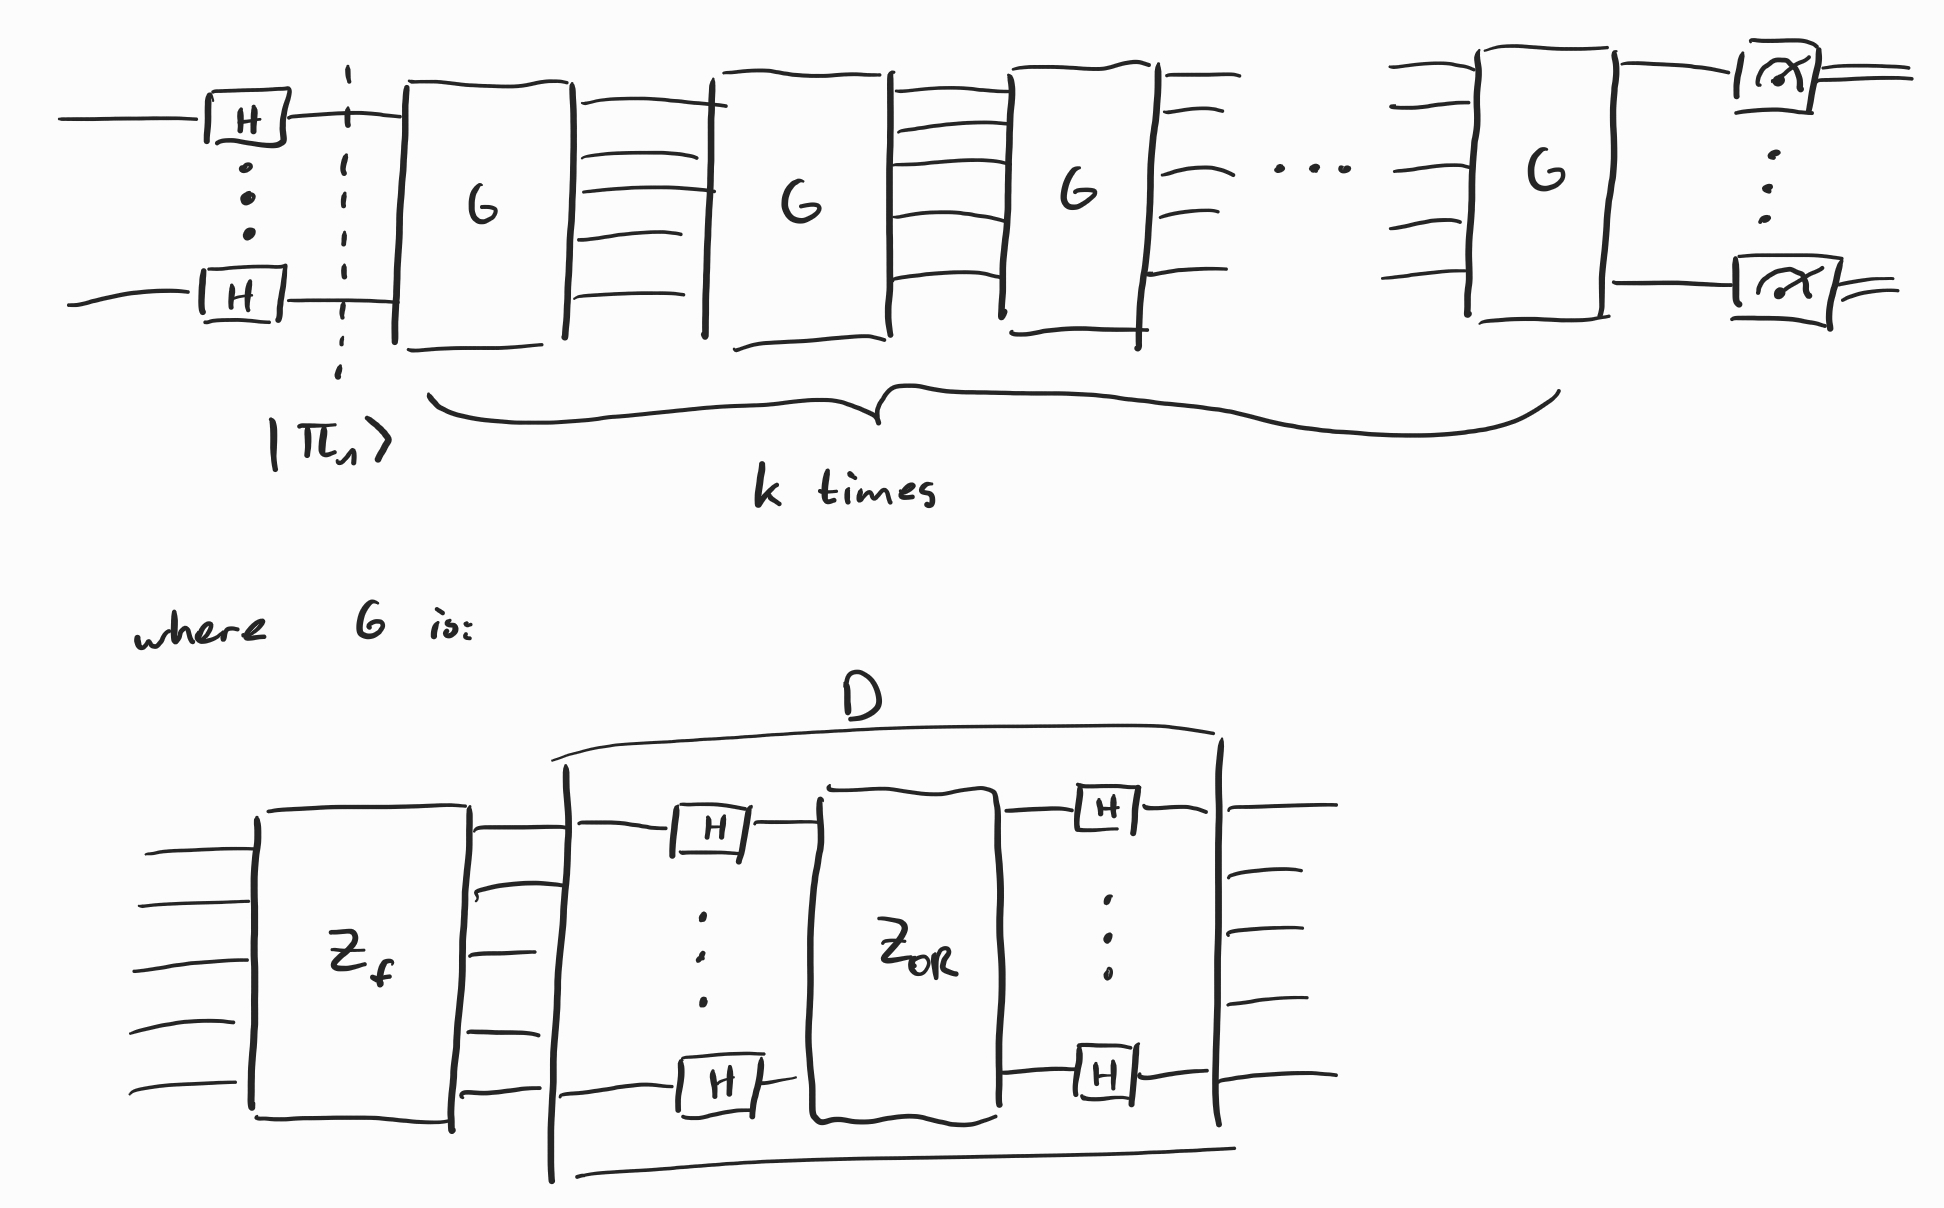

> 💡 **Tipps:**
> - Für $Z_{OR}$ brauchst du ein weiteres `PhaseOracleGate`, diesmal mit einem passenden Ausdruck und z. B. `label='Z_OR'`.
> - `circuit.to_gate(label="G")` wandelt einen kompletten Teil-Circuit in ein einzelnes Gatter `G` um, das du danach wie jedes andere Gatter einsetzen kannst.

In [ ]:
# TODO: Baue die Grover-Iteration G



## Geometrische Herleitung: Wie viele Iterationen brauchen wir?

Bevor du die Anzahl der Iterationen berechnest, schauen wir uns an, **warum** Grovers Algorithmus überhaupt funktioniert – geometrisch betrachtet.

### Der Zwei-Zustands-Raum

Sei $|A_1\rangle$ die gleichverteilte Superposition **aller Lösungen** und $|A_0\rangle$ die gleichverteilte Superposition **aller Nicht-Lösungen**. Diese beiden Zustände stehen senkrecht aufeinander und spannen eine 2-dimensionale Ebene auf.

Der Startzustand nach den ersten Hadamard-Gattern ist die gleichverteilte Superposition **aller** $N$ Zustände:

$$|\psi_+\rangle = \sqrt{\frac{|A_0|}{N}}\,|A_0\rangle + \sqrt{\frac{|A_1|}{N}}\,|A_1\rangle$$

Das lässt sich als ein Vektor in dieser Ebene schreiben, der mit der $|A_0\rangle$-Achse den Winkel $\theta$ einschließt, wobei

$$\sin\!\left(\theta\right) = \sqrt{\frac{|A_1|}{N}}$$

### Was macht eine Grover-Iteration geometrisch?

Man kann zeigen: **Jede Grover-Iteration ist eine Rotation** des Zustandsvektors um den Winkel $2\theta$ **in Richtung** $|A_1\rangle$, innerhalb dieser 2D-Ebene:

- Das Orakel $Z_f$ ist eine Spiegelung an der $|A_0\rangle$-Achse (kippt nur das Vorzeichen der Lösungs-Komponente).
- Der Diffusions-Operator ist eine Spiegelung an der $|\psi_+\rangle$-Achse (dem ursprünglichen Startzustand).
- Zwei Spiegelungen hintereinander ergeben eine **Rotation** um den doppelten Winkel zwischen den beiden Spiegelachsen — und dieser Winkel ist genau $\theta$, also ist die resultierende Rotation $2\theta$.

Die folgenden Diagramme zeigen, wie sich der Zustandsvektor mit jeder Iteration weiter in Richtung $|A_1\rangle$ dreht (Beispielwinkel zur Illustration, nicht exakt):

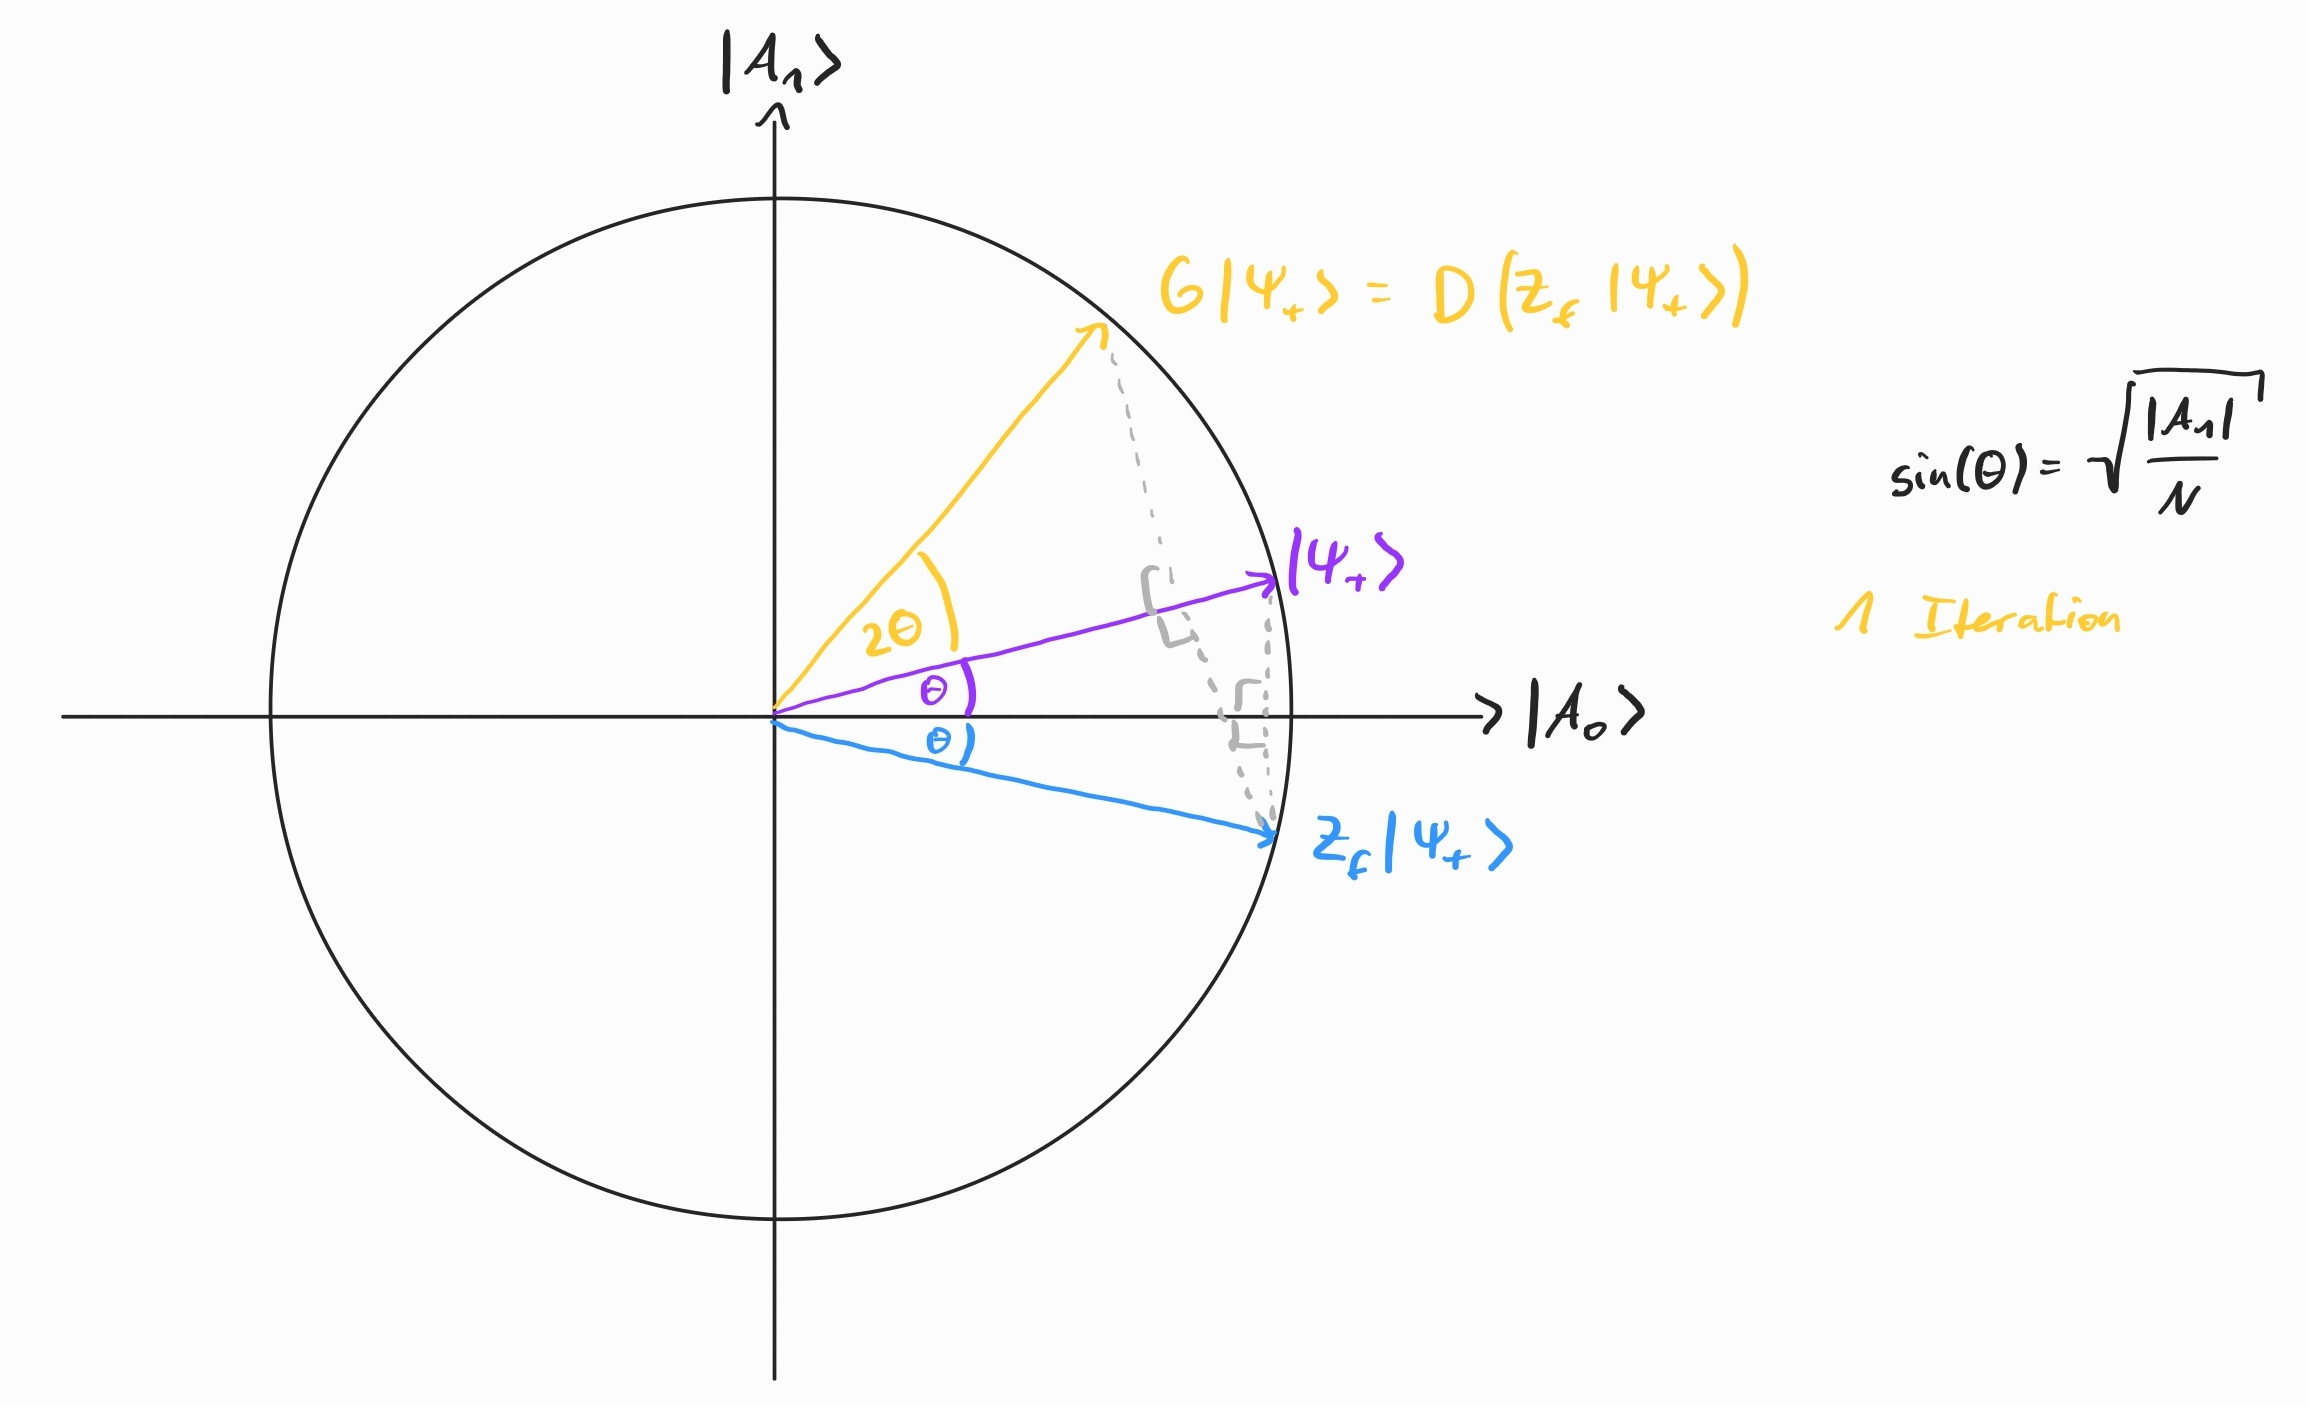

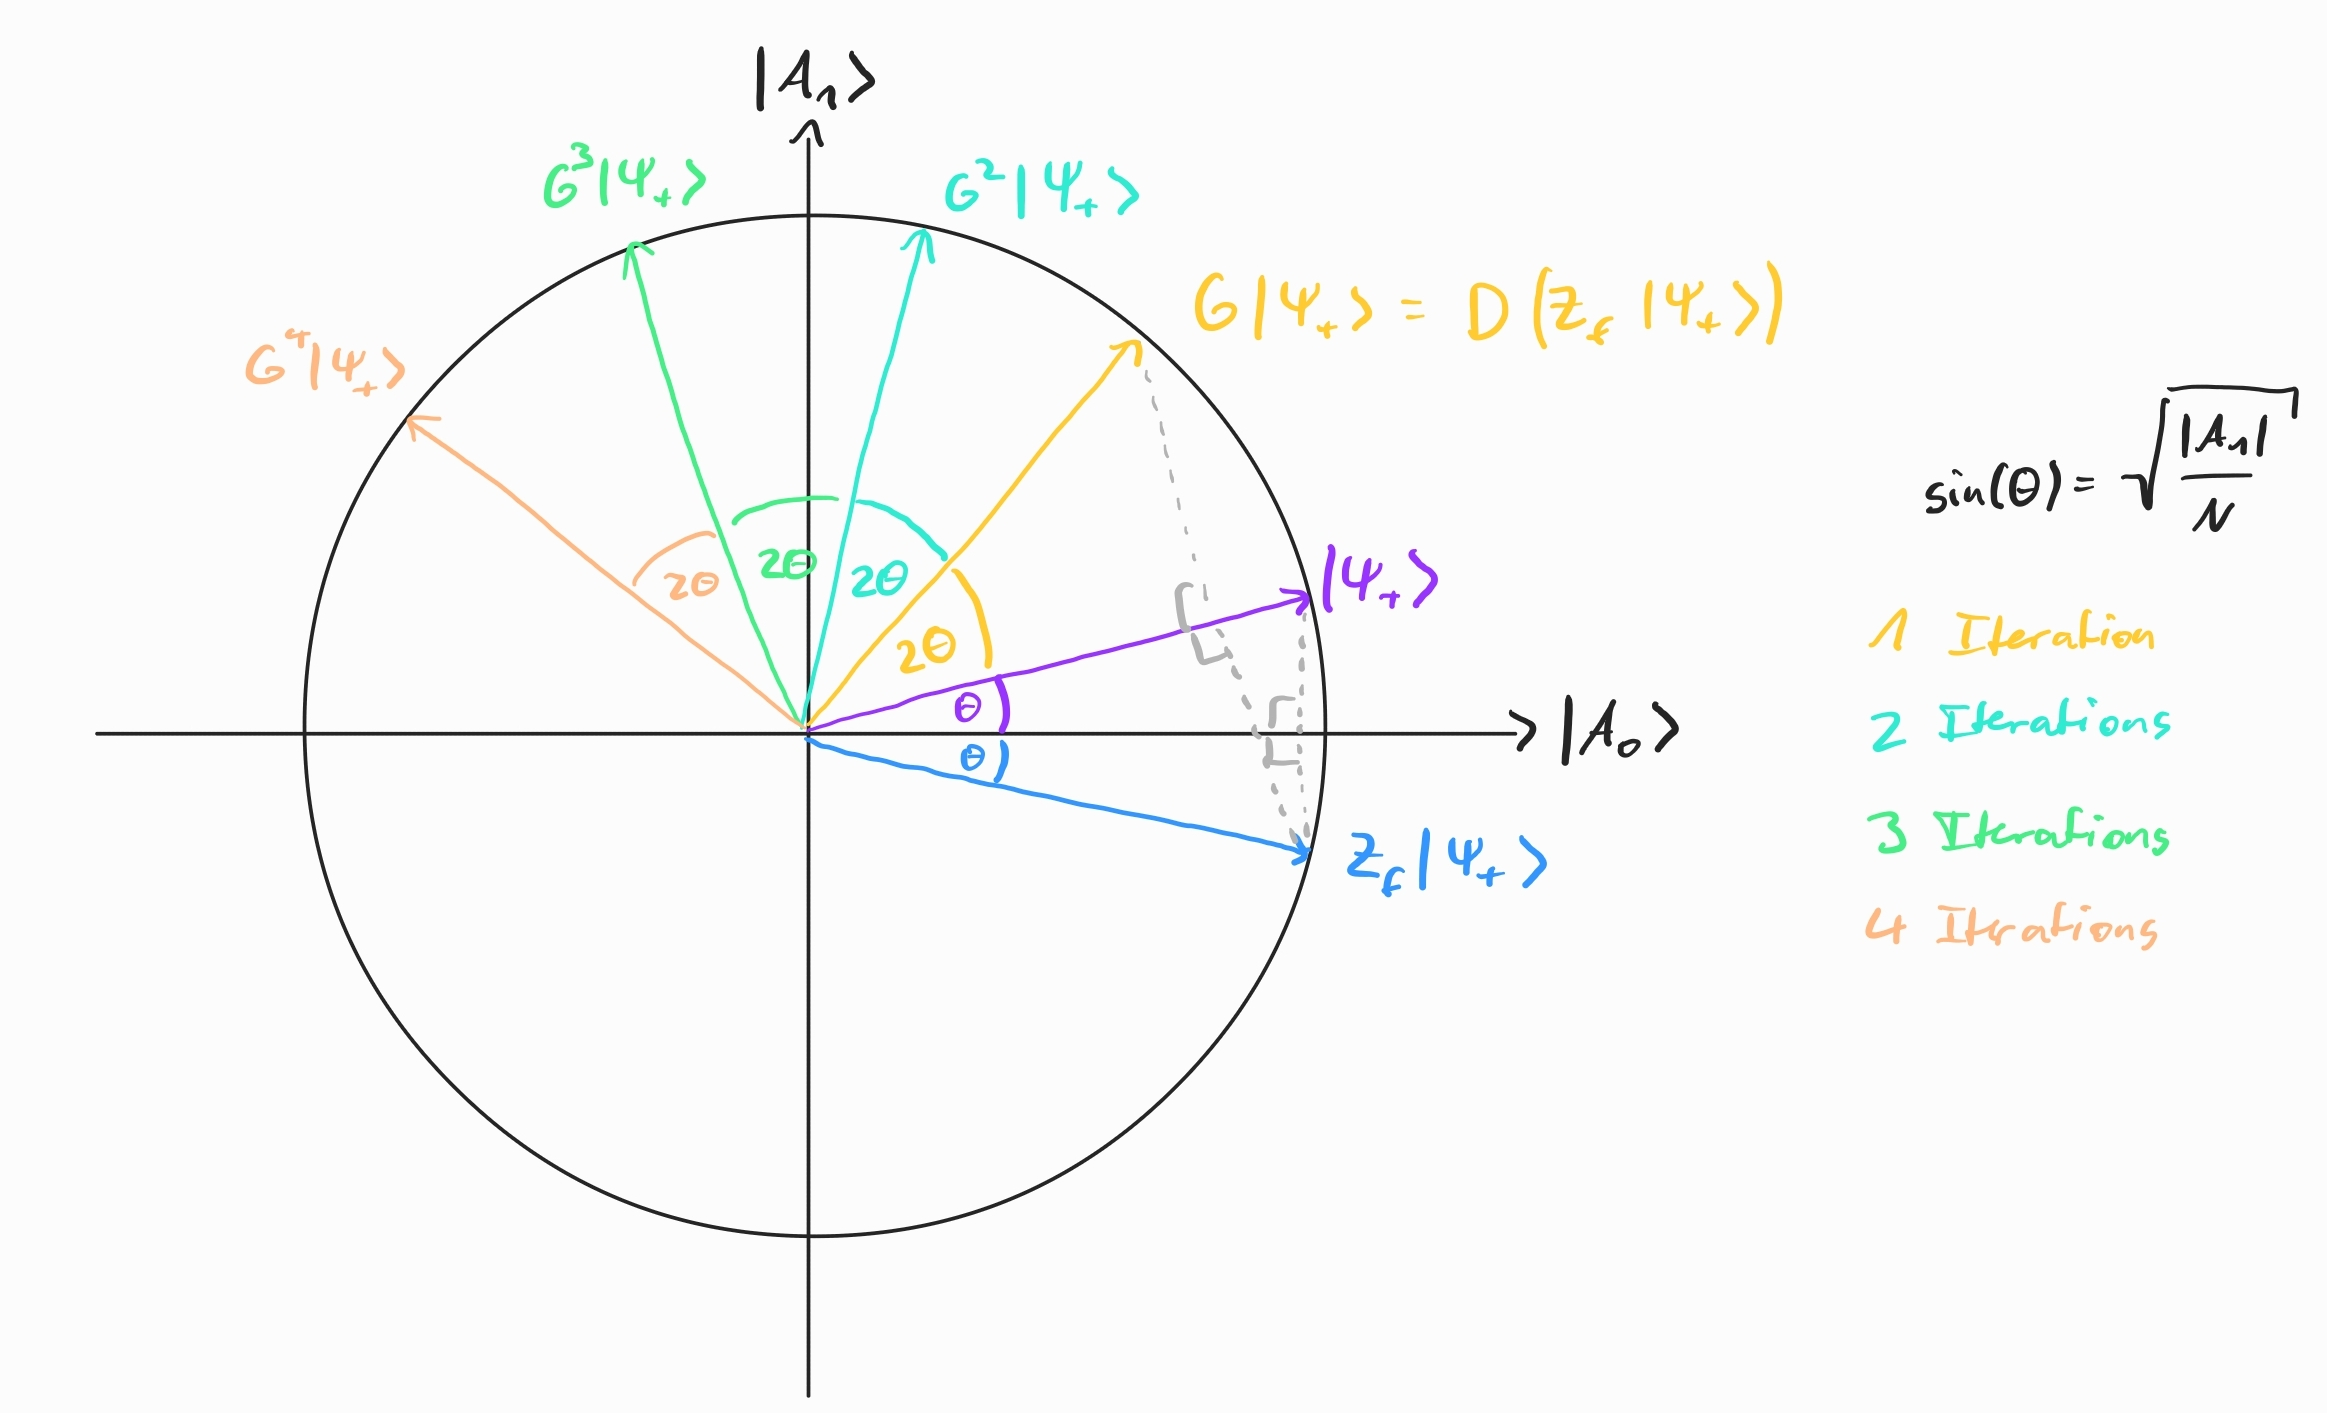

Man erkennt: Nach jeder Iteration wächst der Winkel zur $|A_1\rangle$-Achse um $2\theta$. Nach $k$ Iterationen befindet sich der Zustand im Winkel

$$\left(\theta + 2k\,\theta\right)$$

zur $|A_0\rangle$-Achse. Die Wahrscheinlichkeit, bei einer Messung eine Lösung zu erhalten, ist das Quadrat der Projektion auf die $|A_1\rangle$-Achse:

$$P(k) = \sin^2\!\left(\theta + 2k\,\theta\right)$$

Das letzte Bild oben (nach 3 Iterationen) zeigt bereits eine **Überrotation**: Dreht man zu oft, entfernt sich der Zustand wieder von $|A_1\rangle$! Genau wie bei einem Zeiger, der über das Ziel hinausschießt, wenn man ihn zu weit dreht. Es gibt also ein **Optimum**.

### Optimale Anzahl an Iterationen

$P(k)$ ist maximal (nahe 1), wenn der Winkel $\theta + 2k\theta$ möglichst nahe an $\frac{\pi}{2}$ liegt (dann zeigt der Zustandsvektor fast genau auf $|A_1\rangle$). Wir lösen daher

$$\theta + 2k\,\theta = \frac{\pi}{2} \quad\Longrightarrow\quad k = \frac{\pi/2 - \theta}{2\theta} = \frac{\pi}{4\theta} - \frac{1}{2}$$

Da $\theta$ typischerweise klein ist (wenn $M \ll N$), gilt näherungsweise $\sin(\theta) \approx \theta$, also mit $M = |A_1|$

$$\theta \approx \sqrt{\frac{M}{N}}$$

Eingesetzt ergibt sich die bekannte Formel für die (näherungsweise) optimale Anzahl an Iterationen:

$$k_{opt} \approx \frac{\pi}{4}\sqrt{\frac{N}{M}}$$

Da $k$ eine ganze Zahl sein muss, rundet man üblicherweise ab: $k_{opt} = \left\lfloor \frac{\pi}{4}\sqrt{N/M} \right\rfloor$ (abrunden ist sicherer als aufrunden, da Überrotation die Erfolgswahrscheinlichkeit stärker verschlechtert als leichte Unterrotation).

Das folgende Diagramm zeigt die Periodizität von $P(k)$ und markiert das Optimum:

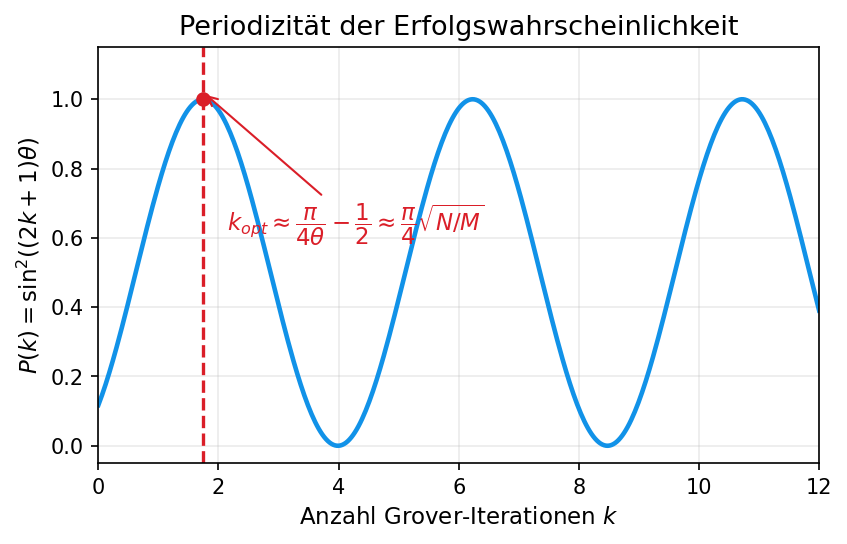

**Deine Aufgabe:** Berechne `num_iterations` nach der Formel $k_{opt} = \left\lfloor \frac{\pi}{4}\sqrt{N/M} \right\rfloor$.

> 💡 **Tipp:** Nutze `np.pi`, `np.sqrt(...)` und `np.floor(...)`, und wandle das Ergebnis mit `int(...)` in eine ganze Zahl um.

In [ ]:
# TODO: Berechne die optimale Anzahl an Grover-Iterationen


## Schritt 4: Den vollständigen Circuit bauen

Jetzt setzen wir alles zusammen:

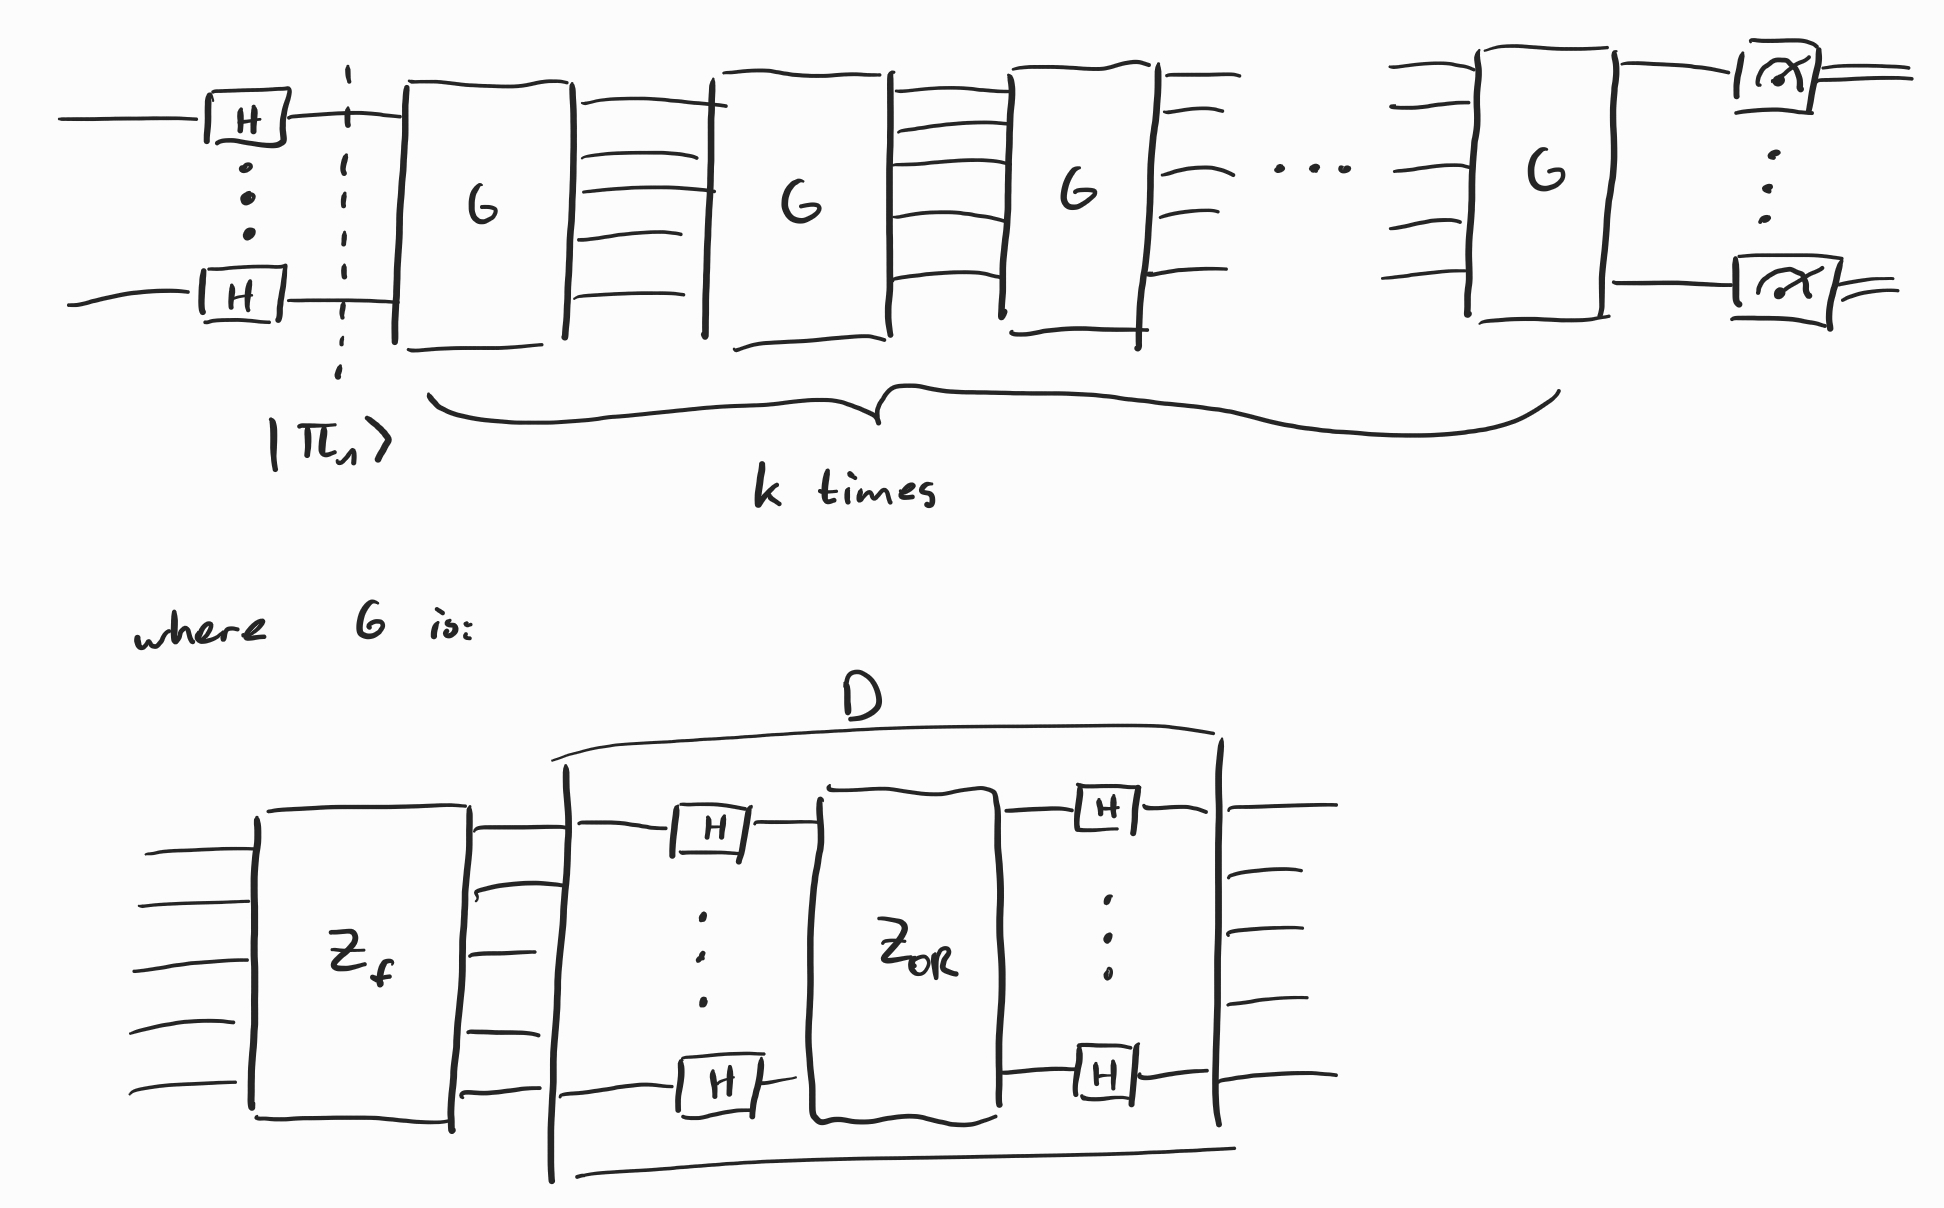

**Deine Aufgabe:** Vervollständige den Circuit `qc`. Die erste Zeile ist bereits gegeben.

> 💡 **Tipps:**
> - `qc.measure_all()` misst automatisch alle Qubits in ein neu angelegtes klassisches Register (du musst dafür keine klassischen Bits selbst anlegen).

In [ ]:
qc = QuantumCircuit(N_QUBITS)


## Schritt 5: Simulation und Auswertung

Zum Schluss lassen wir den Circuit auf einem Simulator laufen und schauen uns die Messergebnisse im Histogramm an. Diese Zelle ist vollständig vorgegeben.

In [ ]:
sampler = StatevectorSampler()
result = sampler.run([qc], shots=2**16).result()
counts = result[0].data.meas.get_counts()

plot_histogram(counts)
plt.show()


## Ergebnis interpretieren

Im Histogramm solltest du sehen, dass die **drei gesuchten Bitstrings** (`keys`, in Little-Endian-Darstellung) mit deutlich höherer Wahrscheinlichkeit gemessen werden als alle anderen 61 möglichen Bitstrings zusammen.

**Zum Ausprobieren:**

1. Verändere `keys`, um nach anderen (oder mehr/weniger) Bitstrings zu suchen. Wie verändert sich `num_iterations`?
2. Was passiert, wenn du absichtlich **doppelt so viele** Iterationen ausführst wie `num_iterations`? Erkläre das Ergebnis anhand der Rotationsdiagramme oben (Stichwort: Überrotation).
3. Was passiert bei **sehr vielen** Lösungen (z. B. $M \approx N/2$)? Was sagt die Formel für $k_{opt}$ dann voraus, und ergibt das Sinn?